# Demo 3: LLM API & Prompt Engineering

Calling an LLM via API: send a prompt, get structured results back. We'll extract clinical findings from real PubMed case reports using progressively more sophisticated prompting techniques, then compare how each technique performs across multiple cases.

## Setup

In [1]:
%pip install -q openai python-dotenv matplotlib numpy pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()

# OpenRouter is an aggregator — same openai SDK, different base_url
if os.environ.get("OPENROUTER_API_KEY"):
    client = OpenAI(
        api_key=os.environ["OPENROUTER_API_KEY"],
        base_url="https://openrouter.ai/api/v1",
    )
    MODEL = "openai/gpt-4o-mini"
    print("Using OpenRouter")
elif os.environ.get("OPENAI_API_KEY"):
    client = OpenAI()
    MODEL = "gpt-4o-mini"
    print("Using OpenAI directly")
else:
    raise ValueError("Set OPENROUTER_API_KEY or OPENAI_API_KEY in a .env file")

Using OpenRouter


## Load Case Reports

Same [PMC-Patients](https://huggingface.co/datasets/zhengyun21/PMC-Patients) dataset we used in Demo 2 — real patient summaries from PubMed Central case reports (Zhao et al., 2023). We'll sample 5 diverse cases for prompt engineering.

In [3]:
pmc = pd.read_json("pmc_patients_sample.json")
print(f"Loaded {len(pmc):,} patient summaries")

# Filter to notes that are a good length for prompting (400-1200 chars)
usable = pmc[pmc["patient"].str.len().between(400, 1200)].reset_index(drop=True)
print(f"{len(usable):,} notes in the 400-1200 char range")

random.seed(2026)
cases = usable.sample(5, random_state=2026)

for i, (_, c) in enumerate(cases.iterrows()):
    print(f"\n--- Case {i+1} (PMID {c['PMID']}) ---")
    print(c["patient"][:150] + "...")

Loaded 500 patient summaries
449 notes in the 400-1200 char range

--- Case 1 (PMID 34581833) ---
An 82-year-old male presented with periprosthetic infection following cemented THA in 2016. Revision surgery involved a two-stage strategy with explan...

--- Case 2 (PMID 20924487) ---
A 68-year-old woman with osteoarthritis of knee and a 20° valgus deformity underwent TKA replacement using a CR design. Clinical examination revealed ...

--- Case 3 (PMID 34667936) ---
An 80-year-old male presented with watering and discharge from his right eye for 1 month. On examination, mild lower eyelid edema and matting of lashe...

--- Case 4 (PMID 36496517) ---
A 31-year-old right-handed man presented with a history of seizures without neurological and cognitive deficits. MRI revealed a lesion characteristic ...

--- Case 5 (PMID 34178485) ---
Patient 1 is a 65-year-old female status post Mohs micrographic surgery for SCC of her right lateral heel. The patient also has multiple actinic kerat...


We'll use the first case for developing our prompts, then test all techniques across all five.

In [4]:
report = cases.iloc[0]["patient"]
print(f"Working case (PMID {cases.iloc[0]['PMID']}):\n")
print(report)

Working case (PMID 34581833):

An 82-year-old male presented with periprosthetic infection following cemented THA in 2016. Revision surgery involved a two-stage strategy with explanation and spacer implantation, combined with antimicrobial therapy. Femoral reimplantation was planned using a cementless revision stem; however, intraoperatively, due to remaining cement distally, the broach went via falsa several times. Due to the high age and several comorbidities, the decision was taken not to use a transfemoral approach, but to perform a trial with the cementless short stem. Finally, an optimys stem combined with a cemented revision cup was implanted. Following revision surgery, the patient was allowed only partial weight bearing.


A reusable helper for calling the LLM.

In [5]:
def call_llm(prompt, system="You are a clinical case analysis assistant.", temperature=0):
    """Send a prompt to the LLM and return the response text."""
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": system},
            {"role": "user", "content": prompt},
        ],
        temperature=temperature,
        max_tokens=500,
    )
    return response.choices[0].message.content

## Zero-Shot Prompting

Zero-shot: describe the task with no examples. Start here; add complexity only if needed.

In [6]:
def zero_shot(note):
    return f"""What is the primary diagnosis in this case report?

Case Report:
{note}

Diagnosis:"""

response = call_llm(zero_shot(report))
print(response)

The primary diagnosis in this case report is periprosthetic infection following total hip arthroplasty (THA).


The model returns free text — a natural language string. That's fine for a human reader, but what if you need to store this in a database, flag it for follow-up, or feed it into another program? You'd have to parse the text with regex or string matching, which is fragile and error-prone.

This is the core tension of this demo: **unstructured output** (free text) vs **structured output** (JSON). We'll try several prompting techniques and compare them across all five cases at the end.

## Few-Shot Prompting

Few-shot provides examples before the actual input. The model infers the pattern from examples rather than instructions alone.

In [7]:
def few_shot(note):
    return f"""Identify the primary diagnosis from clinical case reports.

Example 1:
Case: "A 72-year-old man presented with progressive jaundice and weight loss. CT scan revealed a 3 cm mass in the head of the pancreas. Endoscopic ultrasound-guided biopsy confirmed adenocarcinoma. The patient underwent a Whipple procedure."
Diagnosis: Pancreatic adenocarcinoma

Example 2:
Case: "A 34-year-old woman presented with a two-week history of fatigue, joint pain, and a butterfly-shaped facial rash. ANA was positive at 1:640, anti-dsDNA was elevated. She was started on hydroxychloroquine and low-dose prednisone."
Diagnosis: Systemic lupus erythematosus

Now identify the primary diagnosis:
Case: "{note}"
Diagnosis:"""

response = call_llm(few_shot(report))
print(response)

Periprosthetic joint infection (PJI) following total hip arthroplasty (THA)


Few-shot tends to produce more consistent formatting because the model mirrors the style of the examples.

## Structured Outputs (JSON Extraction)

Free-text responses are hard to use downstream. If you want to write results to a database, pass them to another function, or validate them, you need a **schema** — a contract specifying field names, types, and structure.

The standard approach: put the schema directly in the prompt and tell the model to return _only_ JSON. This is the single most practical technique in this demo — it turns an LLM from a text generator into a data extraction tool.

Note the double braces `{{` / `}}` — Python f-strings use single braces for variable interpolation, so literal braces in JSON must be doubled.

In [8]:
def schema_json(note):
    return f"""Extract clinical information from this case report.
Return ONLY a JSON object with exactly these fields:

{{
  "diagnosis": "<primary diagnosis>",
  "key_findings": ["<list of important clinical findings>"],
  "treatment": "<primary treatment or intervention>",
  "outcome": "<patient outcome if mentioned, else 'not stated'>"
}}

Case Report:
{note}"""

response = call_llm(schema_json(report))
print(response)

{
  "diagnosis": "periprosthetic infection",
  "key_findings": ["82-year-old male", "history of cemented THA in 2016", "revision surgery with two-stage strategy", "remaining cement distally", "high age and several comorbidities", "partial weight bearing post-surgery"],
  "treatment": "revision surgery with explanation and spacer implantation, combined with antimicrobial therapy",
  "outcome": "not stated"
}


The response is usually valid JSON, but LLMs sometimes wrap it in markdown code fences or add commentary. A quick way to handle that:

In [9]:
def clean_json(text):
    """Try to extract a JSON object from LLM output."""
    # Try direct parse first
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass

    # Strip markdown code fences
    if "```" in text:
        lines = text.split("```")
        for block in lines[1::2]:  # odd-indexed segments are inside fences
            block = block.strip().removeprefix("json").strip()
            try:
                return json.loads(block)
            except json.JSONDecodeError:
                continue

    # Find outermost braces
    start, end = text.find("{"), text.rfind("}")
    if start >= 0 and end > start:
        try:
            return json.loads(text[start:end + 1])
        except json.JSONDecodeError:
            pass

    return None


parsed = clean_json(response)
if parsed:
    print(json.dumps(parsed, indent=2))
else:
    print("Could not parse JSON. Raw response:")
    print(response)

{
  "diagnosis": "periprosthetic infection",
  "key_findings": [
    "82-year-old male",
    "history of cemented THA in 2016",
    "revision surgery with two-stage strategy",
    "remaining cement distally",
    "high age and several comorbidities",
    "partial weight bearing post-surgery"
  ],
  "treatment": "revision surgery with explanation and spacer implantation, combined with antimicrobial therapy",
  "outcome": "not stated"
}


Check that the parsed result has the fields we asked for.

In [10]:
if parsed:
    required = {"diagnosis", "key_findings", "treatment", "outcome"}
    has_all = required.issubset(parsed.keys())
    print(f"All fields present: {has_all}")
    for field in sorted(required):
        print(f"  {field}: {parsed.get(field)}")

All fields present: True
  diagnosis: periprosthetic infection
  key_findings: ['82-year-old male', 'history of cemented THA in 2016', 'revision surgery with two-stage strategy', 'remaining cement distally', 'high age and several comorbidities', 'partial weight bearing post-surgery']
  outcome: not stated
  treatment: revision surgery with explanation and spacer implantation, combined with antimicrobial therapy


## Few-Shot + JSON

When zero-shot JSON extraction produces inconsistent schemas (wrong field names, missing fields), adding a complete JSON example anchors the format.

In [11]:
def few_shot_json(note):
    return f"""Extract clinical information from case reports. Return JSON only.

Example:
Case: "A 72-year-old man presented with progressive jaundice and weight loss. CT scan
revealed a 3 cm mass in the head of the pancreas. Endoscopic ultrasound-guided biopsy
confirmed adenocarcinoma. The patient underwent a Whipple procedure with clear margins.
At 12-month follow-up the patient remained disease-free."

Output:
{{
  "diagnosis": "Pancreatic adenocarcinoma",
  "key_findings": ["3 cm pancreatic head mass on CT", "biopsy-confirmed adenocarcinoma"],
  "treatment": "Whipple procedure",
  "outcome": "Disease-free at 12 months"
}}

Now extract from this case:
Case: "{note}"

Output:"""

response = call_llm(few_shot_json(report))
parsed_few = clean_json(response)
print(json.dumps(parsed_few, indent=2) if parsed_few else response)

{
  "diagnosis": "Periprosthetic infection following total hip arthroplasty (THA)",
  "key_findings": [
    "History of cemented THA in 2016",
    "Revision surgery with two-stage strategy",
    "Intraoperative challenges with remaining cement"
  ],
  "treatment": "Revision surgery with cementless short stem and cemented revision cup, combined with antimicrobial therapy",
  "outcome": "Partial weight bearing allowed post-surgery"
}


The example anchors field names, value formats, and output style. Models mirror what they see.

## Chain-of-Thought Prompting

Chain-of-thought (CoT) asks the model to reason step by step before producing the answer. By "thinking out loud," the model is less likely to skip details or make errors on complex cases. The tradeoff: more output tokens (slower, costs more), but often higher accuracy and — critically — **visible reasoning** you can audit.

In [12]:
def chain_of_thought(note):
    return f"""Analyze the clinical case report below.

First, reason through these questions step by step:
1. What are the key clinical findings?
2. What is the primary diagnosis?
3. What treatment or intervention was performed?
4. What was the patient's outcome?

Then produce the final JSON:
{{
  "diagnosis": "<primary diagnosis>",
  "key_findings": ["<important findings>"],
  "treatment": "<primary treatment>",
  "outcome": "<patient outcome>"
}}

Case Report:
{note}"""

response = call_llm(chain_of_thought(report))
print(response)

Let's analyze the clinical case report step by step:

1. **Key Clinical Findings**:
   - The patient is an 82-year-old male.
   - He has a history of periprosthetic infection following a total hip arthroplasty (THA) in 2016.
   - Revision surgery was performed using a two-stage strategy involving explanation and spacer implantation.
   - There were complications during the surgery due to remaining cement distally, which affected the broaching process.
   - The patient has several comorbidities, which influenced the surgical approach.

2. **Primary Diagnosis**:
   - The primary diagnosis is a periprosthetic infection following total hip arthroplasty (THA).

3. **Treatment or Intervention Performed**:
   - The treatment involved a two-stage revision surgery with explanation and spacer implantation, followed by the implantation of an optimys stem combined with a cemented revision cup.

4. **Patient's Outcome**:
   - Following the revision surgery, the patient was allowed only partial weig

In [13]:
parsed_cot = clean_json(response)
if parsed_cot:
    print("\nExtracted JSON:")
    print(json.dumps(parsed_cot, indent=2))


Extracted JSON:
{
  "diagnosis": "periprosthetic infection following total hip arthroplasty",
  "key_findings": [
    "82-year-old male",
    "history of periprosthetic infection",
    "revision surgery with two-stage strategy",
    "complications due to remaining cement",
    "several comorbidities"
  ],
  "treatment": "two-stage revision surgery with explanation and spacer implantation, followed by implantation of optimys stem and cemented revision cup",
  "outcome": "patient allowed only partial weight bearing"
}


The reasoning is visible (useful for debugging) and the same `clean_json` function works — it finds the JSON block at the end regardless of the preceding text.

## Comparing Across All Five Cases

Now the real test: run every technique on every case. A single example can't tell you whether few-shot beats zero-shot — you need multiple cases to see patterns.

In [14]:
techniques = {
    "Zero-shot":       ("text", zero_shot),
    "Few-shot":        ("text", few_shot),
    "Schema JSON":     ("json", schema_json),
    "Few-shot JSON":   ("json", few_shot_json),
    "Chain-of-thought":("json", chain_of_thought),
}

# Run all techniques on all cases
results = {}
for case_idx, (_, case) in enumerate(cases.iterrows()):
    note = case["patient"]
    pmid = case["PMID"]
    results[pmid] = {}
    for tech_name, (output_type, prompt_fn) in techniques.items():
        raw = call_llm(prompt_fn(note))
        parsed = clean_json(raw) if output_type == "json" else None
        results[pmid][tech_name] = {
            "raw": raw,
            "parsed": parsed,
            "valid_json": parsed is not None if output_type == "json" else None,
            "has_all_fields": (
                {"diagnosis", "key_findings", "treatment", "outcome"}.issubset(parsed.keys())
                if parsed else False
            ) if output_type == "json" else None,
        }
    print(f"Case {case_idx + 1} (PMID {pmid}): done")

print(f"\nProcessed {len(cases)} cases × {len(techniques)} techniques = {len(cases) * len(techniques)} API calls")

Case 1 (PMID 34581833): done


Case 2 (PMID 20924487): done


Case 3 (PMID 34667936): done


Case 4 (PMID 36496517): done


Case 5 (PMID 34178485): done

Processed 5 cases × 5 techniques = 25 API calls


### JSON Validity and Schema Compliance

How often does each structured technique produce valid, complete JSON?

In [15]:
json_techniques = [t for t, (otype, _) in techniques.items() if otype == "json"]

print(f"{'Technique':<22} {'Valid JSON':>12} {'All Fields':>12}")
print("-" * 48)
for tech in json_techniques:
    valid = sum(1 for pmid in results if results[pmid][tech]["valid_json"])
    complete = sum(1 for pmid in results if results[pmid][tech]["has_all_fields"])
    print(f"{tech:<22} {valid:>8}/{len(cases):<4} {complete:>8}/{len(cases)}")

Technique                Valid JSON   All Fields
------------------------------------------------
Schema JSON                   5/5           5/5
Few-shot JSON                 5/5           4/5
Chain-of-thought              5/5           5/5


### Side-by-Side Comparison

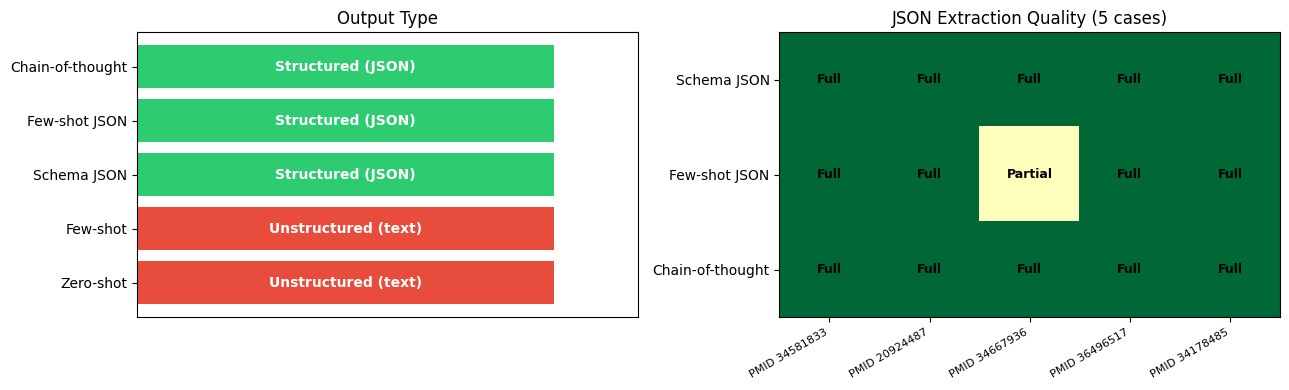

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: output type by technique
tech_names = list(techniques.keys())
is_structured = [techniques[t][0] == "json" for t in tech_names]
colors = ['#2ecc71' if s else '#e74c3c' for s in is_structured]

axes[0].barh(tech_names, [1] * len(tech_names), color=colors)
axes[0].set_xlim(0, 1.2)
axes[0].set_xticks([])
axes[0].set_title('Output Type')
for i, (t, s) in enumerate(zip(tech_names, is_structured)):
    axes[0].text(0.5, i, 'Structured (JSON)' if s else 'Unstructured (text)',
                 ha='center', va='center', fontweight='bold', color='white')

# Right: heatmap of valid JSON + all fields across cases
case_labels = [f"PMID {c['PMID']}" for _, c in cases.iterrows()]
score_matrix = []
for tech in json_techniques:
    row = []
    for _, case in cases.iterrows():
        r = results[case["PMID"]][tech]
        # 0 = failed parse, 0.5 = valid JSON but missing fields, 1.0 = complete
        if r["has_all_fields"]:
            row.append(1.0)
        elif r["valid_json"]:
            row.append(0.5)
        else:
            row.append(0.0)
    score_matrix.append(row)

score_array = np.array(score_matrix)
im = axes[1].imshow(score_array, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
axes[1].set_xticks(range(len(case_labels)))
axes[1].set_xticklabels(case_labels, rotation=30, ha='right', fontsize=8)
axes[1].set_yticks(range(len(json_techniques)))
axes[1].set_yticklabels(json_techniques)
axes[1].set_title('JSON Extraction Quality (5 cases)')

labels = {0.0: "Fail", 0.5: "Partial", 1.0: "Full"}
for i in range(len(json_techniques)):
    for j in range(len(cases)):
        axes[1].text(j, i, labels[score_array[i, j]],
                     ha='center', va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

### Inspect Extractions

In [17]:
for _, case in cases.iterrows():
    pmid = case["PMID"]
    print(f"\n{'='*60}")
    print(f"PMID {pmid}: {case['patient'][:100]}...")
    for tech in json_techniques:
        p = results[pmid][tech]["parsed"]
        diag = p.get("diagnosis", "???") if p else "(parse failed)"
        print(f"  {tech:<22} → {diag}")


PMID 34581833: An 82-year-old male presented with periprosthetic infection following cemented THA in 2016. Revision...
  Schema JSON            → periprosthetic infection
  Few-shot JSON          → Periprosthetic infection following total hip arthroplasty (THA)
  Chain-of-thought       → periprosthetic infection following total hip arthroplasty

PMID 20924487: A 68-year-old woman with osteoarthritis of knee and a 20° valgus deformity underwent TKA replacement...
  Schema JSON            → osteoarthritis of knee
  Few-shot JSON          → Knee dislocation post-TKA
  Chain-of-thought       → Complications following total knee arthroplasty (dislocation due to flexion-extension gap mismatch)

PMID 34667936: An 80-year-old male presented with watering and discharge from his right eye for 1 month. On examina...
  Schema JSON            → canaliculitis
  Few-shot JSON          → Canaliculitis
  Chain-of-thought       → canaliculitis

PMID 36496517: A 31-year-old right-handed man presented wi

These techniques — structured prompts, JSON schemas, parsing strategies — generalize to any extraction task. The specific schema and domain change; the prompting patterns stay the same.